In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
DATASET_DIR = "../planetsdataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "training")
VALID_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

In [3]:
CLASS_NAMES = sorted([
    folder_name
    for folder_name in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder_name))
])
CLASS_NAMES.remove("black_hole")
CLASS_NAMES.remove("galaxy")
print("Classes:", CLASS_NAMES)

Classes: ['asteroid', 'earth', 'jupiter', 'mars', 'mercury', 'moon', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']


In [4]:
def load_images_from_split(split_dir, class_names, img_size=(64, 64)):
    X = []
    y = []

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(split_dir, class_name)

        if not os.path.isdir(class_dir):
            print(f"Warning: folder not found: {class_dir}")
            continue

        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)

            try:
                img = Image.open(file_path).convert("RGB")
                img = img.resize(img_size)
                img_array = np.array(img, dtype=np.float32) / 255.0
                X.append(img_array.flatten())
                y.append(label)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    return np.array(X), np.array(y)

In [5]:
IMG_SIZE = (64, 64)

X_train, y_train = load_images_from_split(TRAIN_DIR, CLASS_NAMES, IMG_SIZE)
print("train images loaded")
X_valid, y_valid = load_images_from_split(VALID_DIR, CLASS_NAMES, IMG_SIZE)
print("validation images loaded")
X_test, y_test = load_images_from_split(TEST_DIR, CLASS_NAMES, IMG_SIZE)
print("test images loaded")

train images loaded
validation images loaded
test images loaded


In [6]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2247, 12288) (2247,)
Validation: (618, 12288) (618,)
Test: (312, 12288) (312,)


In [7]:
model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42)

In [8]:
y_valid_pred = model.predict(X_valid)

print("\nValidation Accuracy:", accuracy_score(y_valid, y_valid_pred))
print("\nValidation Report:")
print(classification_report(y_valid, y_valid_pred, target_names=CLASS_NAMES))


Validation Accuracy: 0.8446601941747572

Validation Report:
              precision    recall  f1-score   support

    asteroid       0.57      0.50      0.53        42
       earth       0.87      0.90      0.88        59
     jupiter       0.73      0.77      0.75        57
        mars       0.93      0.93      0.93        61
     mercury       0.81      0.91      0.86        57
        moon       0.75      0.72      0.73        57
     neptune       0.93      0.91      0.92        57
       pluto       0.81      0.81      0.81        57
      saturn       0.85      0.79      0.82        57
      uranus       0.97      0.98      0.97        57
       venus       0.98      0.96      0.97        57

    accuracy                           0.84       618
   macro avg       0.84      0.84      0.84       618
weighted avg       0.84      0.84      0.84       618



In [9]:
y_test_pred = model.predict(X_test)

print("\nValidation Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nValidation Report:")
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES))


Validation Accuracy: 0.8044871794871795

Validation Report:
              precision    recall  f1-score   support

    asteroid       0.65      0.52      0.58        29
       earth       0.86      0.83      0.84        29
     jupiter       0.73      0.68      0.70        28
        mars       0.85      0.97      0.91        30
     mercury       0.88      0.79      0.83        28
        moon       0.61      0.61      0.61        28
     neptune       0.93      0.93      0.93        28
       pluto       0.66      0.89      0.76        28
      saturn       0.74      0.82      0.78        28
      uranus       1.00      0.96      0.98        28
       venus       1.00      0.86      0.92        28

    accuracy                           0.80       312
   macro avg       0.81      0.80      0.80       312
weighted avg       0.81      0.80      0.80       312



In [12]:
import joblib
joblib.dump(model, "planet_classifier.joblib")

['planet_classifier.joblib']

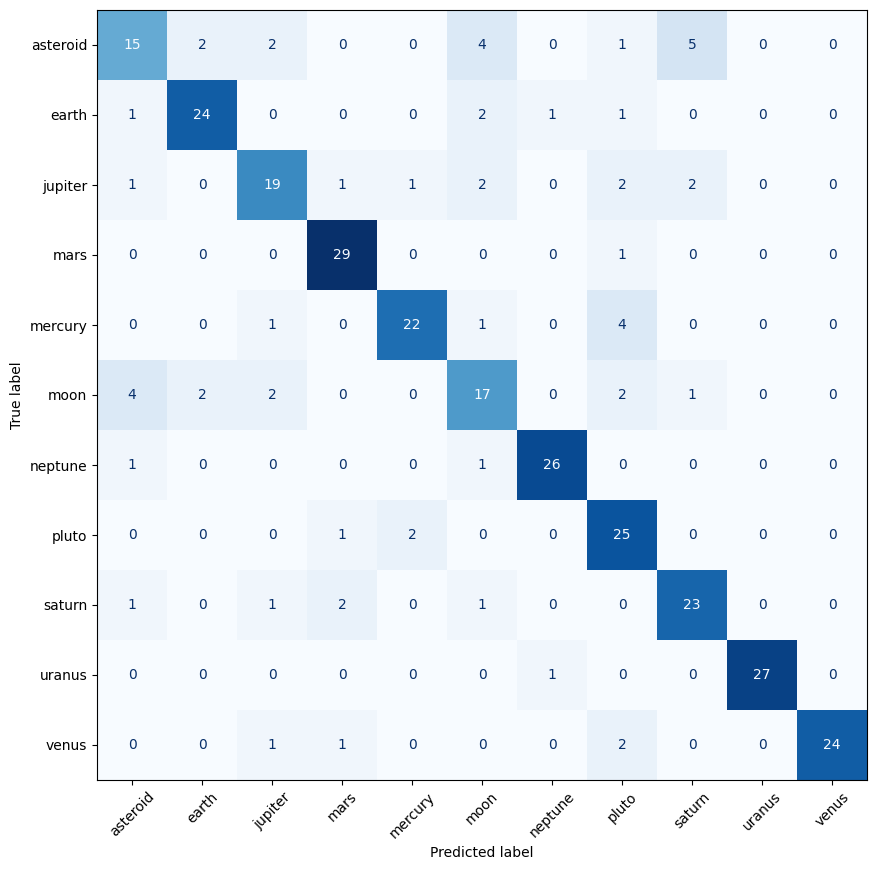

In [15]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.show()

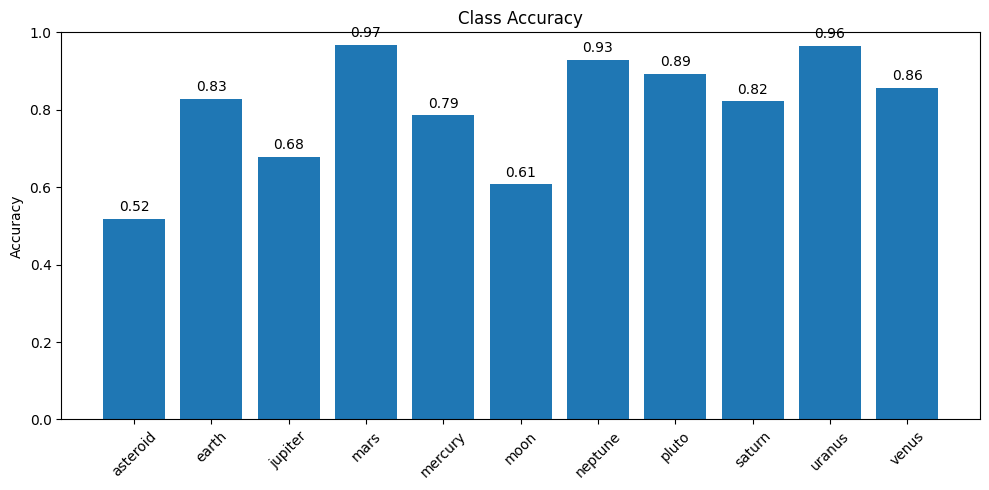

In [19]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(CLASS_NAMES, per_class_accuracy)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Class Accuracy")
plt.xticks(rotation=45)

for i, acc in enumerate(per_class_accuracy):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha="center")

plt.tight_layout()
plt.show()